# Dynamic Defender Context

This experiment keeps the snap-to-release target, `delta_sep = sep_release - sep_snap`, and asks whether defenders' movement before the pass release helps predict it. It is a controlled feature ablation: static ridge and dynamic ridge use the same game-grouped train/validation/test split. Dynamic features summarize the three PFF coverage defenders nearest the route runner at the snap, following those same defender identities until (but not including) the release frame.

These features describe defensive motion and are not direct measures of receiver route quality. In particular, they are not separation measurements, and the results do not establish a causal receiver-versus-defender attribution.

In [1]:
from pathlib import Path
import csv
import math
import sys
from collections import Counter, defaultdict

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from separation_over_expected.feature_schema import DYNAMIC_CONTEXT_FEATURES
from separation_over_expected.reports import read_csv_rows

DATA_DIR = PROJECT_ROOT / "data" / "processed" / "dynamic_features"
MODEL_DIR = DATA_DIR / "position_baselines"
route_rows = read_csv_rows(DATA_DIR / "route_level_snap_to_release_dynamic.csv")
len(route_rows), len(route_rows[0]), len(DYNAMIC_CONTEXT_FEATURES)

(35032, 85, 24)

## What was added

At the snap, coverage defenders are ranked by Euclidean distance to each route runner. The three identities are fixed for the route. For each defender we summarize pre-release speed, acceleration, normalized depth/width displacement, path length, cumulative heading change, and observed-frame fraction. Dynamic numeric missingness is imputed with training-partition means; no validation or test values contribute to imputation.

In [2]:
dynamic_missingness = {
    feature: sum(row[feature] == "" for row in route_rows) / len(route_rows)
    for feature in DYNAMIC_CONTEXT_FEATURES
}
feature_coverage = {
    "route_rows": len(route_rows),
    "unique_route_keys": len({(r["gameId"], r["playId"], r["nflId"]) for r in route_rows}),
    "dynamic_feature_count": len(DYNAMIC_CONTEXT_FEATURES),
    "missing_fraction_by_feature": dynamic_missingness,
    "rank_1_observed_fraction_at_least_80pct": sum(
        float(r["defender_1_observed_fraction_pre_release"]) >= 0.8 for r in route_rows
    ) / len(route_rows),
}
feature_coverage

{'route_rows': 35032, 'unique_route_keys': 35032, 'dynamic_feature_count': 24, 'missing_fraction_by_feature': {'defender_1_mean_speed_pre_release': 0.0, 'defender_1_max_speed_pre_release': 0.0, 'defender_1_mean_accel_pre_release': 0.0, 'defender_1_depth_displacement_pre_release': 0.0, 'defender_1_width_displacement_pre_release': 0.0, 'defender_1_path_length_pre_release': 0.0, 'defender_1_total_turn_degrees_pre_release': 0.0, 'defender_1_observed_fraction_pre_release': 0.0, 'defender_2_mean_speed_pre_release': 0.0, 'defender_2_max_speed_pre_release': 0.0, 'defender_2_mean_accel_pre_release': 0.0, 'defender_2_depth_displacement_pre_release': 0.0, 'defender_2_width_displacement_pre_release': 0.0, 'defender_2_path_length_pre_release': 0.0, 'defender_2_total_turn_degrees_pre_release': 0.0, 'defender_2_observed_fraction_pre_release': 0.0, 'defender_3_mean_speed_pre_release': 0.0, 'defender_3_max_speed_pre_release': 0.0, 'defender_3_mean_accel_pre_release': 0.0, 'defender_3_depth_displacement

## Split integrity

The split is stratified by week and groups every game into exactly one partition. Pooled and position-specific experiments reuse the same seed and splitting routine; the static comparator below is also checked against the previously completed game-split run.

In [3]:
all_predictions = read_csv_rows(MODEL_DIR / "route_level_baseline_predictions_all.csv")
by_split = {s: [r for r in all_predictions if r["split"] == s] for s in ("train", "validation", "test")}
games = {s: {r["gameId"] for r in values} for s, values in by_split.items()}
split_integrity = {
    s: {"routes": len(values), "games": len(games[s]), "weeks": sorted({int(r["week"]) for r in values})}
    for s, values in by_split.items()
}
overlap = {
    f"{a}/{b}": len(games[a] & games[b])
    for a, b in (("train", "validation"), ("train", "test"), ("validation", "test"))
}
split_integrity, overlap

({'train': {'routes': 24463, 'games': 85, 'weeks': [1, 2, 3, 4, 5, 6, 7, 8]}, 'validation': {'routes': 4497, 'games': 16, 'weeks': [1, 2, 3, 4, 5, 6, 7, 8]}, 'test': {'routes': 6072, 'games': 21, 'weeks': [1, 2, 3, 4, 5, 6, 7, 8]}}, {'train/validation': 0, 'train/test': 0, 'validation/test': 0})

## Model comparison

Report validation and test scores for the static and dynamic ridge models. Validation is useful for iteration; test results are the final held-out comparison. The test set contains unseen games but games are sampled from all eight weeks, so this measures same-season generalization rather than forecasting a future season.

In [4]:
groups = [("All", "all"), ("WR", "wr"), ("TE", "te"), ("RB", "rb")]
comparison = []
for group, suffix in groups:
    metrics = read_csv_rows(MODEL_DIR / f"baseline_metrics_{suffix}.csv")
    for split in ("validation", "test"):
        for model in ("ridge_context", "ridge_dynamic_context"):
            r = next(row for row in metrics if row["split"] == split and row["model"] == model)
            comparison.append({"group": group, "split": split, "model": model, "r2": r["r2"], "rmse": r["rmse"], "mae": r["mae"], "n": r["n"]})
comparison

[{'group': 'All', 'split': 'validation', 'model': 'ridge_context', 'r2': '0.334', 'rmse': '2.339', 'mae': '1.717', 'n': '4497'}, {'group': 'All', 'split': 'validation', 'model': 'ridge_dynamic_context', 'r2': '0.357', 'rmse': '2.298', 'mae': '1.694', 'n': '4497'}, {'group': 'All', 'split': 'test', 'model': 'ridge_context', 'r2': '0.340', 'rmse': '2.392', 'mae': '1.746', 'n': '6072'}, {'group': 'All', 'split': 'test', 'model': 'ridge_dynamic_context', 'r2': '0.358', 'rmse': '2.359', 'mae': '1.733', 'n': '6072'}, {'group': 'WR', 'split': 'validation', 'model': 'ridge_context', 'r2': '0.496', 'rmse': '1.837', 'mae': '1.360', 'n': '2628'}, {'group': 'WR', 'split': 'validation', 'model': 'ridge_dynamic_context', 'r2': '0.510', 'rmse': '1.812', 'mae': '1.339', 'n': '2628'}, {'group': 'WR', 'split': 'test', 'model': 'ridge_context', 'r2': '0.479', 'rmse': '1.967', 'mae': '1.432', 'n': '3527'}, {'group': 'WR', 'split': 'test', 'model': 'ridge_dynamic_context', 'r2': '0.500', 'rmse': '1.928', '

In [5]:
test_deltas = []
for group, suffix in groups:
    metrics = read_csv_rows(MODEL_DIR / f"baseline_metrics_{suffix}.csv")
    static = next(r for r in metrics if r["split"] == "test" and r["model"] == "ridge_context")
    dynamic = next(r for r in metrics if r["split"] == "test" and r["model"] == "ridge_dynamic_context")
    test_deltas.append({"group": group, "static_r2": static["r2"], "dynamic_r2": dynamic["r2"], "r2_change": f'{float(dynamic["r2"]) - float(static["r2"]):+.3f}', "static_rmse": static["rmse"], "dynamic_rmse": dynamic["rmse"], "rmse_change": f'{float(dynamic["rmse"]) - float(static["rmse"]):+.3f}', "test_routes": static["n"]})
test_deltas

[{'group': 'All', 'static_r2': '0.340', 'dynamic_r2': '0.358', 'r2_change': '+0.018', 'static_rmse': '2.392', 'dynamic_rmse': '2.359', 'rmse_change': '-0.033', 'test_routes': '6072'}, {'group': 'WR', 'static_r2': '0.479', 'dynamic_r2': '0.500', 'r2_change': '+0.021', 'static_rmse': '1.967', 'dynamic_rmse': '1.928', 'rmse_change': '-0.039', 'test_routes': '3527'}, {'group': 'TE', 'static_r2': '0.266', 'dynamic_r2': '0.284', 'r2_change': '+0.018', 'static_rmse': '2.369', 'dynamic_rmse': '2.341', 'rmse_change': '-0.028', 'test_routes': '1390'}, {'group': 'RB', 'static_r2': '0.237', 'dynamic_r2': '0.288', 'r2_change': '+0.051', 'static_rmse': '3.243', 'dynamic_rmse': '3.132', 'rmse_change': '-0.111', 'test_routes': '1070'}]

The static scores should reproduce the earlier game-grouped baseline exactly. This guards against accidental changes to the target, rows, or split while adding dynamic columns.

In [6]:
old_dir = PROJECT_ROOT / "data" / "processed" / "game_split" / "position_baselines"
static_reproduction = []
for group, suffix in groups:
    old = read_csv_rows(old_dir / f"baseline_metrics_{suffix}.csv")
    new = read_csv_rows(MODEL_DIR / f"baseline_metrics_{suffix}.csv")
    old_row = next(r for r in old if r["split"] == "test" and r["model"] == "ridge_context")
    new_row = next(r for r in new if r["split"] == "test" and r["model"] == "ridge_context")
    static_reproduction.append({"group": group, **{key: (old_row[key], new_row[key], old_row[key] == new_row[key]) for key in ("r2", "rmse", "mae", "n")}})
static_reproduction

[{'group': 'All', 'r2': ('0.340', '0.340', True), 'rmse': ('2.392', '2.392', True), 'mae': ('1.746', '1.746', True), 'n': ('6072', '6072', True)}, {'group': 'WR', 'r2': ('0.479', '0.479', True), 'rmse': ('1.967', '1.967', True), 'mae': ('1.432', '1.432', True), 'n': ('3527', '3527', True)}, {'group': 'TE', 'r2': ('0.266', '0.266', True), 'rmse': ('2.369', '2.369', True), 'mae': ('1.724', '1.724', True), 'n': ('1390', '1390', True)}, {'group': 'RB', 'r2': ('0.237', '0.237', True), 'rmse': ('3.243', '3.243', True), 'mae': ('2.546', '2.546', True), 'n': ('1070', '1070', True)}]

## Route trajectory diagnostic

The model receives route-level motion summaries. To make those summaries tangible, the next cell plots the nearest PFF coverage defender's distance to one illustrative receiver over the route. This chart is an explanatory diagnostic; it is not the response being predicted, and the chosen nearest defender can change from frame to frame in this plot.

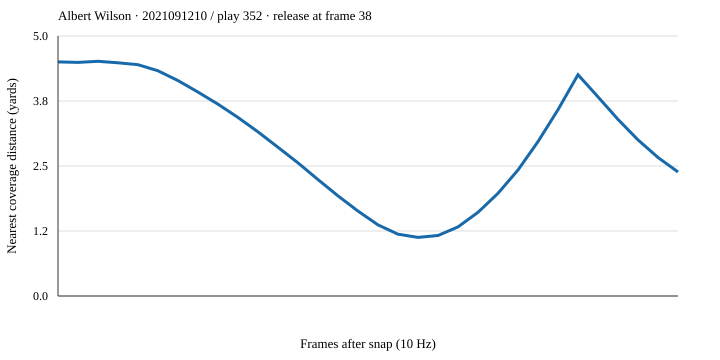

In [7]:
class SVG:
    def __init__(self, markup):
        self.markup = markup
    def _repr_svg_(self):
        return self.markup

test_keys = {(r["gameId"], r["playId"], r["nflId"]) for r in all_predictions if r["officialPosition"] == "WR" and r["split"] == "test"}
eligible = [r for r in route_rows if r["officialPosition"] == "WR" and (r["gameId"], r["playId"], r["nflId"]) in test_keys]
example = sorted(eligible, key=lambda r: (abs(float(r["delta_sep"])), r["gameId"], r["playId"]))[len(eligible)//2]
week = int(example["week"])
tracking_path = PROJECT_ROOT.parent / "data" / "big_data_bowl_2023" / f"week{week}.csv"
pff_path = PROJECT_ROOT.parent / "data" / "big_data_bowl_2023" / "pffScoutingData.csv"
coverage_ids = set()
with pff_path.open(newline="") as f:
    for row in csv.DictReader(f):
        if row["gameId"] == example["gameId"] and row["playId"] == example["playId"] and row["pff_role"] == "Coverage":
            coverage_ids.add(row["nflId"])
snap_frame, release_frame = int(example["snap_frame"]), int(example["release_frame"])
trajectory = defaultdict(dict)
with tracking_path.open(newline="") as f:
    for row in csv.DictReader(f):
        if row["gameId"] == example["gameId"] and row["playId"] == example["playId"] and snap_frame <= int(row["frameId"]) <= release_frame and row["nflId"] != "":
            trajectory[int(row["frameId"])][row["nflId"]] = (float(row["x"]), float(row["y"]))
series = []
receiver_id = example["nflId"]
for frame in sorted(trajectory):
    if snap_frame <= frame < release_frame and receiver_id in trajectory[frame]:
        rx, ry = trajectory[frame][receiver_id]
        distances = [math.dist((rx, ry), trajectory[frame][d]) for d in coverage_ids if d in trajectory[frame]]
        if distances:
            series.append((frame - snap_frame, min(distances)))

width, height, left, top, plot_w, plot_h = 720, 360, 58, 36, 620, 260
max_x = max((x for x, _ in series), default=1)
max_y = max(5.0, max((y for _, y in series), default=5.0))
points = " ".join(f"{left+x/max_x*plot_w:.1f},{top+plot_h-y/max_y*plot_h:.1f}" for x, y in series)
grid = "".join(f'<line x1="{left}" y1="{top+i*plot_h/4:.0f}" x2="{left+plot_w}" y2="{top+i*plot_h/4:.0f}" stroke="#ddd"/><text x="{left-10}" y="{top+i*plot_h/4+4:.0f}" text-anchor="end" font-size="12">{max_y*(1-i/4):.1f}</text>' for i in range(5))
svg = SVG(f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}"><rect width="100%" height="100%" fill="white"/>{grid}<polyline points="{points}" fill="none" stroke="#1769aa" stroke-width="3"/><line x1="{left}" y1="{top}" x2="{left}" y2="{top+plot_h}" stroke="#333"/><line x1="{left}" y1="{top+plot_h}" x2="{left+plot_w}" y2="{top+plot_h}" stroke="#333"/><text x="{left+plot_w/2}" y="{height-12}" text-anchor="middle" font-size="13">Frames after snap (10 Hz)</text><text x="16" y="{top+plot_h/2}" transform="rotate(-90 16 {top+plot_h/2})" text-anchor="middle" font-size="13">Nearest coverage distance (yards)</text><text x="{left}" y="20" font-size="13">{example["displayName"]} · {example["gameId"]} / play {example["playId"]} · release at frame {release_frame}</text></svg>')
svg

## Interpretation and next validation

Dynamic context improves the held-out metrics in this experiment, with the clearest result for WR and RB. This is evidence that defender movement contains predictive information beyond snap-level context for this target. It is not yet evidence that we have isolated receiver skill: defender motion can encode coverage behavior, route combinations, pressure, and play design. The three defenders are chosen using snap-time proximity, which is an operational proxy for coverage responsibility.

Next, inspect feature ablations and residuals, test sensitivity to the 80% frame-coverage threshold and defender ranking, and evaluate season-to-season persistence if comparable tracking data becomes available. Treat player-level dynamic SOE summaries as exploratory until that validation is done.

## Validation diagnostics

The following diagnostics use validation only to decide whether the dynamic result is robust. The test set remains report-only. Subgroup differences are descriptive: small groups can have noisy scores, and a split-by-week view is not a future-season test.

In [8]:
from separation_over_expected.models import (
    RidgeContextModel,
    RidgeDynamicContextModel,
    regression_metrics,
    split_rows,
    target,
)
from separation_over_expected.reports import pearson_correlation
import random
import statistics

validation_rows = [r for r in all_predictions if r["split"] == "validation"]

def grouped_residual_comparison(rows, group_name, group_fn):
    groups_for_rows = defaultdict(list)
    for row in rows:
        groups_for_rows[group_fn(row)].append(row)
    result = []
    for label, group_rows in sorted(groups_for_rows.items(), key=lambda pair: str(pair[0])):
        actual = [float(r["delta_sep"]) for r in group_rows]
        static_pred = [float(r["pred_delta_sep_ridge_context"]) for r in group_rows]
        dynamic_pred = [float(r["pred_delta_sep_ridge_dynamic_context"]) for r in group_rows]
        sm, dm = regression_metrics(actual, static_pred), regression_metrics(actual, dynamic_pred)
        result.append({"grouping": group_name, "group": label, "n": len(group_rows), "static_rmse": sm["rmse"], "dynamic_rmse": dm["rmse"], "rmse_change": f'{float(dm["rmse"])-float(sm["rmse"]):+.3f}', "static_bias": sm["bias"], "dynamic_bias": dm["bias"]})
    return result

wr_validation = [r for r in validation_rows if r["officialPosition"] == "WR"]
subgroup_checks = []
subgroup_checks += grouped_residual_comparison(validation_rows, "position", lambda r: r["officialPosition"])
subgroup_checks += grouped_residual_comparison(wr_validation, "week", lambda r: r["week"])
subgroup_checks += grouped_residual_comparison(wr_validation, "coverage_type", lambda r: r["pff_passCoverageType"] or "unknown")
subgroup_checks += grouped_residual_comparison(wr_validation, "throw_time", lambda r: "<10 frames" if int(r["time_to_throw_frames"]) < 10 else "10-14 frames" if int(r["time_to_throw_frames"]) < 15 else "15-19 frames" if int(r["time_to_throw_frames"]) < 20 else "20+ frames")
subgroup_checks

[{'grouping': 'position', 'group': 'C', 'n': 2, 'static_rmse': '1.404', 'dynamic_rmse': '1.489', 'rmse_change': '+0.085', 'static_bias': '-1.403', 'dynamic_bias': '-1.487'}, {'grouping': 'position', 'group': 'FB', 'n': 46, 'static_rmse': '2.527', 'dynamic_rmse': '2.455', 'rmse_change': '-0.072', 'static_bias': '0.622', 'dynamic_bias': '0.678'}, {'grouping': 'position', 'group': 'QB', 'n': 8, 'static_rmse': '2.750', 'dynamic_rmse': '2.758', 'rmse_change': '+0.008', 'static_bias': '-2.224', 'dynamic_bias': '-2.288'}, {'grouping': 'position', 'group': 'RB', 'n': 787, 'static_rmse': '3.393', 'dynamic_rmse': '3.262', 'rmse_change': '-0.131', 'static_bias': '0.031', 'dynamic_bias': '0.032'}, {'grouping': 'position', 'group': 'TE', 'n': 1026, 'static_rmse': '2.388', 'dynamic_rmse': '2.395', 'rmse_change': '+0.007', 'static_bias': '-0.115', 'dynamic_bias': '-0.083'}, {'grouping': 'position', 'group': 'WR', 'n': 2628, 'static_rmse': '1.884', 'dynamic_rmse': '1.866', 'rmse_change': '-0.018', 'st

Residuals should not retain a strong pattern with starting separation or route duration. These quartile summaries compare signed bias and RMSE for WR validation routes; they help identify remaining structure, but are not a feature-selection license to repeatedly tune against validation.

In [9]:
def quartile_group(rows, feature):
    ordered = sorted(rows, key=lambda r: float(r[feature]))
    output = defaultdict(list)
    for index, row in enumerate(ordered):
        quartile = min(4, 1 + (4 * index // len(ordered)))
        output[f"Q{quartile}"].append(row)
    return output

residual_pattern_checks = []
for feature, label in (("sep_snap", "starting separation"), ("time_to_throw_frames", "throw time")):
    for quartile, group_rows in sorted(quartile_group(wr_validation, feature).items()):
        actual = [float(r["delta_sep"]) for r in group_rows]
        dynamic_pred = [float(r["pred_delta_sep_ridge_dynamic_context"]) for r in group_rows]
        metrics = regression_metrics(actual, dynamic_pred)
        residual_pattern_checks.append({"feature": label, "quartile": quartile, "n": len(group_rows), "mean_feature": f'{statistics.fmean(float(r[feature]) for r in group_rows):.2f}', "dynamic_bias": metrics["bias"], "dynamic_rmse": metrics["rmse"]})
residual_pattern_checks

[{'feature': 'starting separation', 'quartile': 'Q1', 'n': 657, 'mean_feature': '2.37', 'dynamic_bias': '0.029', 'dynamic_rmse': '1.418'}, {'feature': 'starting separation', 'quartile': 'Q2', 'n': 657, 'mean_feature': '4.30', 'dynamic_bias': '0.006', 'dynamic_rmse': '1.772'}, {'feature': 'starting separation', 'quartile': 'Q3', 'n': 657, 'mean_feature': '6.40', 'dynamic_bias': '-0.137', 'dynamic_rmse': '1.948'}, {'feature': 'starting separation', 'quartile': 'Q4', 'n': 657, 'mean_feature': '8.81', 'dynamic_bias': '-0.323', 'dynamic_rmse': '2.232'}, {'feature': 'throw time', 'quartile': 'Q1', 'n': 657, 'mean_feature': '19.16', 'dynamic_bias': '0.067', 'dynamic_rmse': '1.531'}, {'feature': 'throw time', 'quartile': 'Q2', 'n': 657, 'mean_feature': '24.51', 'dynamic_bias': '-0.293', 'dynamic_rmse': '1.634'}, {'feature': 'throw time', 'quartile': 'Q3', 'n': 657, 'mean_feature': '29.79', 'dynamic_bias': '-0.079', 'dynamic_rmse': '1.963'}, {'feature': 'throw time', 'quartile': 'Q4', 'n': 657,

## Defender-rank and frame-coverage sensitivity

Refit WR ridge models using only rank-1, ranks 1–2, and ranks 1–3 dynamic summaries, with the identical game split and static context. All routes have complete tracking for all three selected defenders (`observed_fraction = 1.0`), so thresholds of 80%, 90%, and 100% retain exactly the same observations. This dataset therefore cannot distinguish those thresholds; a future dataset with gaps should repeat the check.

In [10]:
rank_feature_sensitivity = []
model_splits = split_rows(route_rows, strategy="game", seed=42, train_fraction=0.70, validation_fraction=0.15)
train_wr = [r for r in model_splits["train"] if r["officialPosition"] == "WR"]
valid_wr = [r for r in model_splits["validation"] if r["officialPosition"] == "WR"]
static_features = list(RidgeContextModel.numeric_features)
for max_rank in (1, 2, 3):
    selected_dynamic = [f for f in DYNAMIC_CONTEXT_FEATURES if int(f.split("_")[1]) <= max_rank]
    model = RidgeDynamicContextModel(l2=25.0, max_levels_per_feature=30)
    model.name = f"nearest_{max_rank}"
    model.numeric_features = static_features + selected_dynamic
    model.fit(train_wr)
    actual = [target(r) for r in valid_wr]
    predicted = [model.predict(r) for r in valid_wr]
    rank_feature_sensitivity.append({"defenders": max_rank, **regression_metrics(actual, predicted)})
rank_feature_sensitivity

[{'defenders': 1, 'mae': '1.346', 'rmse': '1.820', 'r2': '0.505', 'bias': '-0.072', 'mean_actual': '-2.452', 'mean_predicted': '-2.380', 'n': '2628'}, {'defenders': 2, 'mae': '1.341', 'rmse': '1.813', 'r2': '0.509', 'bias': '-0.066', 'mean_actual': '-2.452', 'mean_predicted': '-2.387', 'n': '2628'}, {'defenders': 3, 'mae': '1.339', 'rmse': '1.812', 'r2': '0.510', 'bias': '-0.065', 'mean_actual': '-2.452', 'mean_predicted': '-2.388', 'n': '2628'}]

## Receiver-level split reliability

To see whether player residual averages depend on a few games, split the validation games into two deterministic halves, calculate each WR's mean dynamic residual in each half, and correlate players with at least five routes in both halves. A player-level bootstrap interval reflects uncertainty from the eligible receiver sample; it does not represent a population-wide season-to-season reliability estimate.

In [11]:
game_ids = sorted({r["gameId"] for r in wr_validation})
random.Random(42).shuffle(game_ids)
half_games = (set(game_ids[:len(game_ids)//2]), set(game_ids[len(game_ids)//2:]))
player_half_values = [defaultdict(list), defaultdict(list)]
for row in wr_validation:
    for half, selected_games in enumerate(half_games):
        if row["gameId"] in selected_games:
            player_half_values[half][(row["nflId"], row["displayName"])].append(float(row["soe_route_ridge_dynamic_context"]))
paired = [(statistics.fmean(player_half_values[0][key]), statistics.fmean(player_half_values[1][key])) for key in sorted(player_half_values[0].keys() & player_half_values[1].keys()) if len(player_half_values[0][key]) >= 5 and len(player_half_values[1][key]) >= 5]
xs, ys = [p[0] for p in paired], [p[1] for p in paired]
point_correlation = pearson_correlation(xs, ys)
bootstrap_correlations = []
bootstrap_rng = random.Random(2026)
for _ in range(2000):
    sample = [paired[bootstrap_rng.randrange(len(paired))] for _ in paired]
    bootstrap_correlations.append(pearson_correlation([p[0] for p in sample], [p[1] for p in sample]))
bootstrap_correlations.sort()
receiver_reliability = {"validation_games_per_half": [len(x) for x in half_games], "eligible_receivers": len(paired), "receiver_routes_minimum_per_half": 5, "correlation": round(point_correlation, 3), "bootstrap_95pct_interval": [round(bootstrap_correlations[49], 3), round(bootstrap_correlations[1949], 3)]}
receiver_reliability

{'validation_games_per_half': [8, 8], 'eligible_receivers': 13, 'receiver_routes_minimum_per_half': 5, 'correlation': -0.136, 'bootstrap_95pct_interval': [-0.634, 0.371]}

## What these checks say

On WR validation routes, adding ranks 2 and 3 yields only a small gain over rank 1 (RMSE 1.820 → 1.813 → 1.812). The aggregate improvement is not uniform: the validation RMSE is slightly better for zone coverage and slightly worse for man coverage, while week-level differences are small. Residuals also become more negative in the highest snap-separation quartile, which means the model tends to overpredict separation change there.

The receiver split-half correlation is -0.136 for 13 eligible receivers, with a wide 95% bootstrap interval (-0.634, 0.371). This is too uncertain to conclude that dynamic route residuals provide stable player rankings. It is a warning that improved route-level prediction has not yet demonstrated dependable player-level evaluation. No result here substitutes for validation on another season; only one season's first eight weeks are available in this dataset.